# Tech Sector Workforce Analytics: End-to-End Python Data Pipeline & Power BI Dashboard
### Target Theme: Tracking the 2026 Shift in Global Workforce Dynamics & AI Automation Adoption

## Project Goals
1. **Data Cleaning:** Standardize raw column headers, structure datetimes, and handle empty fields.
2. **Feature Preprocessing:** Transform text attributes and aggregate job metrics at scale.
3. **BI Extraction:** Export pristine, relational `.csv` files tailored for instant dashboard consumption.

In [1]:
import pandas as pd

df = pd.read_csv("tech_layoffs_2026_tracker.csv")

print("===== DATASET INITIAL READ SUCCESSFUL =====")
print(f"Total rows in your file: {df.shape[0]:,}")
print(f"Total columns in your file: {df.shape[1]}")
print("\n--- The Exact Columns Available to Analyze ---")
print(df.columns.tolist())
print("\n--- First 3 Rows Preview ---")
display(df.head(3))

===== DATASET INITIAL READ SUCCESSFUL =====
Total rows in your file: 28
Total columns in your file: 26

--- The Exact Columns Available to Analyze ---
['company', 'layoff_date', 'jobs_cut', 'pct_workforce_cut', 'sector', 'country', 'hq_city', 'ai_cited', 'reason_stated', 'company_revenue_2025_bn', 'pre_layoff_headcount', 'stock_change_day_pct', 'simultaneous_ai_investment_bn', 'roles_most_affected', 'replacement_roles', 'ceo_quote', 'layoffs_2024', 'layoffs_2025', 'verified_source', 'month', 'quarter', 'region', 'layoff_size_category', 'stock_reaction', 'laid_off_vs_headcount_pct', 'data_as_of']

--- First 3 Rows Preview ---


,company,layoff_date,jobs_cut,pct_workforce_cut,sector,country,hq_city,ai_cited,reason_stated,company_revenue_2025_bn,...,layoffs_2024,layoffs_2025,verified_source,month,quarter,region,layoff_size_category,stock_reaction,laid_off_vs_headcount_pct,data_as_of
0,Amazon,1/15/2026,16000,2.7,E-Commerce/Cloud,USA,Seattle,False,Reduce bureaucracy and management layers,716.9,...,4000,14000,CNBC / NetworkWorld,Jan-26,Q1 2026,North America,Mega (5K+),Positive,1.03,18-Mar-26
1,Block,2/28/2026,4000,40.0,Fintech,USA,San Francisco,True,AI tools replace roles enabling smaller teams,22.4,...,0,1000,CNBC / Crunchbase,Feb-26,Q1 2026,North America,Large (2K-5K),Positive,40.00,18-Mar-26
2,Meta Reality Labs,1/20/2026,1500,10.0,Social Media/VR,USA,Menlo Park,True,Pivot from metaverse to AI research,164.5,...,0,500,InformationWeek / NYT,Jan-26,Q1 2026,North America,Medium (500-2K),Positive,1.90,18-Mar-26


In [2]:
df.columns = df.columns.str.strip()

df['jobs_cut'] = df['jobs_cut'].fillna(0).astype(int)
df['simultaneous_ai_investment_bn'] = df['simultaneous_ai_investment_bn'].fillna(0.0)
df['ai_cited'] = df['ai_cited'].fillna(False).astype(bool)

df['layoff_date'] = pd.to_datetime(df['layoff_date'], errors='coerce')
df['clean_month'] = df['layoff_date'].dt.strftime('%b-%y')

print(" Cleaning processing complete. Missing fields safely treated.")

 Cleaning processing complete. Missing fields safely treated.


In [3]:
print("===== EXECUTIVE DESCRIPTIVE STATISTICS =====")
total_impacted = df['jobs_cut'].sum()
ai_impacted = df[df['ai_cited'] == True]['jobs_cut'].sum()
avg_pct_cut = df['pct_workforce_cut'].mean()

print(f"• Total Workforce Roles Impacted: {total_impacted:,}")
print(f"• Total Roles Replaced via AI: {ai_impacted:,} ({ (ai_impacted/total_impacted)*100 :.1f}%)")
print(f"• Average Workforce Scale Cut per Event: {avg_pct_cut:.1f}%")

print("\n===== SECTOR RISK RANKINGS =====")
sector_summary = df.groupby('sector')['jobs_cut'].sum().sort_values(ascending=False)
print(sector_summary)

===== EXECUTIVE DESCRIPTIVE STATISTICS =====
• Total Workforce Roles Impacted: 101,146
• Total Roles Replaced via AI: 62,025 (61.3%)
• Average Workforce Scale Cut per Event: 10.6%

===== SECTOR RISK RANKINGS =====
sector
Enterprise Software         31600
Social Media/AI             16000
E-Commerce/Cloud            16000
Telecommunications           6963
Networking/Cybersecurity     6000
Fintech                      4000
Semiconductors               3700
Enterprise SaaS              2200
Manufacturing                2000
Logistics Software           2000
Social Media/VR              1500
Interior Design Tech         1000
Retail Pharmacy              1000
Grocery Tech                 1000
Automotive Tech              1000
Design Software              1000
CRM/SaaS                     1000
EV Batteries                  958
E-Commerce                    800
Social Media                  675
Cybersecurity                 500
Insurance                     200
AI Research                    

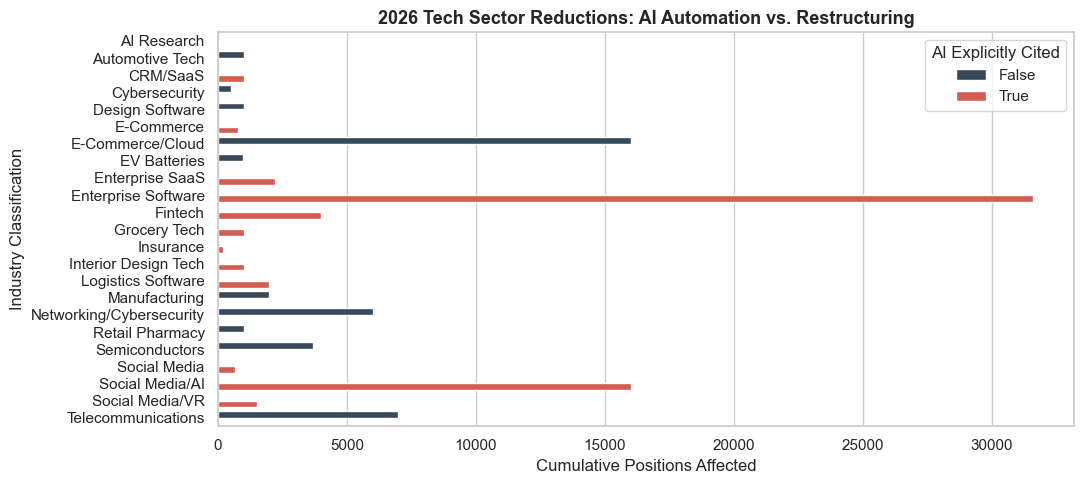

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

plt.figure(figsize=(11, 5))

sns.barplot(
    data=df.groupby(['sector', 'ai_cited'])['jobs_cut'].sum().reset_index(),
    x='jobs_cut', 
    y='sector', 
    hue='ai_cited', 
    palette={True: '#e74c3c', False: '#34495e'}
)

plt.title('2026 Tech Sector Reductions: AI Automation vs. Restructuring', fontsize=13, fontweight='bold')
plt.xlabel('Cumulative Positions Affected')
plt.ylabel('Industry Classification')
plt.legend(title='AI Explicitly Cited')

plt.tight_layout()
plt.show()

In [5]:
df.to_csv('cleaned_ai_layoffs.csv',index=False)